80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.


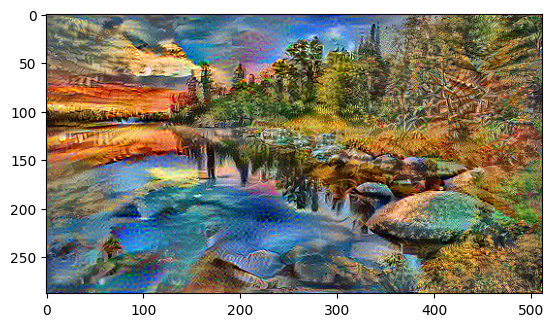

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def load_and_process_img(path_to_img):
    max_dim = 512
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim
    new_shape = tf.cast(shape * scale, tf.int32)

    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]
    return img

def deprocess_img(processed_img):
    x = processed_img * 255
    x = np.array(x, dtype=np.uint8)
    if np.ndim(x) > 3:
        x = x[0]
    return x

# 2. Load pretrained VGG19 & Extract Layers
content_layers = ['block5_conv2']
style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']

def vgg_layers(layer_names):
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False # Freeze weights
    outputs = [vgg.get_layer(name).output for name in layer_names]
    model = tf.keras.Model([vgg.input], outputs)
    return model

# 3. Define Loss Functions
def gram_matrix(input_tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
    return result / num_locations

class StyleContentModel(tf.keras.models.Model):
    def __init__(self, style_layers, content_layers):
        super(StyleContentModel, self).__init__()
        self.vgg = vgg_layers(style_layers + content_layers)
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)
        self.vgg.trainable = False

    def call(self, inputs):
        inputs = inputs * 255.0
        preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)
        outputs = self.vgg(preprocessed_input)
        style_outputs, content_outputs = (outputs[:self.num_style_layers], outputs[self.num_style_layers:])
        style_dict = {style_name: value for style_name, value in zip(self.style_layers, style_outputs)}
        content_dict = {content_name: value for content_name, value in zip(self.content_layers, content_outputs)}
        return {'content': content_dict, 'style': style_dict}

# Replace these with your chosen CIFAR-10/WikiArt paths or other files
content_path = 'beautiful_scene.jpg'
style_path = 'plain-poster-scenery.jpg'

content_image = load_and_process_img(content_path)
style_image = load_and_process_img(style_path)

extractor = StyleContentModel(style_layers, content_layers)
style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']

image = tf.Variable(content_image)

# Weights for Total Loss
style_weight = 1e-2
content_weight = 1e4

opt = tf.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

# 4. Implement loss-based image optimization
@tf.function()
def train_step(image):
    with tf.GradientTape() as tape:
        outputs = extractor(image)

        # Style loss
        style_loss = tf.add_n([tf.reduce_mean((gram_matrix(outputs['style'][name]) - gram_matrix(style_targets[name]))**2)
                               for name in outputs['style'].keys()])
        style_loss *= style_weight / len(style_layers)

        # Content loss
        content_loss = tf.add_n([tf.reduce_mean((outputs['content'][name] - content_targets[name])**2)
                                 for name in outputs['content'].keys()])
        content_loss *= content_weight / len(content_layers)

        # Total loss
        loss = style_loss + content_loss

    grad = tape.gradient(loss, image)
    opt.apply_gradients([(grad, image)])
    image.assign(tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0))

# Run the optimization
epochs = 10
steps_per_epoch = 100

for n in range(epochs):
    for m in range(steps_per_epoch):
        train_step(image)
    print(f"Epoch {n+1}/{epochs} completed.")

# Final output should show content structure preserved and style texture transferred
plt.imshow(deprocess_img(image.numpy()))
plt.show()